## Hyperparameter Optimization — BiLSTM Multivariate + Cyclical (Optuna)

Notebook ini melakukan **hyperparameter tuning** menggunakan **Optuna** terhadap model dengan performa terbaik dari eksperimen sebelumnya: **BiLSTM Multivariate + Cyclical Features** (`05_dani_dl_cyclical.ipynb`), yang menghasilkan RMSE terendah untuk CI maupun RE dibanding lima konfigurasi Deep Learning lainnya (Uni-LSTM, Uni-BiLSTM, Multi-LSTM).

**Scope tuning**
- Model: BiLSTM Multivariate — CI & RE tetap diprediksi bersama dalam satu model (`output_dim=2`)
- Horizon: one-step-ahead, konsisten dengan notebook 04–05
- Fitur: identik dengan notebook 05 (PACF lag features + cyclical time features `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos`)

**Hyperparameter yang dituning (skema "Lengkap")**

| Kategori | Hyperparameter | Search space |
|---|---|---|
| Window | `look_back` | {12, 24, 48, 72} jam |
| Arsitektur | tipe layer | LSTM vs BiLSTM |
| Arsitektur | jumlah stacked layer | 1–3 |
| Arsitektur | units per layer | {32, 64, 96, 128, 192, 256} |
| Regularisasi | dropout per layer | 0.0–0.5 (step 0.05) |
| Optimisasi | learning rate | 1e-4 – 1e-2 (log-scale) |
| Optimisasi | batch size | {16, 32, 64, 128} |

- **Objective yang di-minimize**: rata-rata *scaled* validation MSE gabungan CI+RE (lihat penjelasan di bawah)
- **Budget**: ~40 trial (kisaran sedang, 30–50), dengan `MedianPruner` untuk menghentikan trial yang jelas tidak kompetitif lebih awal
- **Test set disisihkan sepenuhnya** — Optuna hanya melihat training-internal validation split, supaya pemilihan hyperparameter tidak bocor ke test set

---

### Kenapa "rata-rata scaled MSE" berarti CI dan RE sama penting?

Model BiLSTM Multi memiliki satu `Dense(2)` output layer yang memprediksi CI dan RE sekaligus, dengan loss `mse` dihitung pada ruang hasil Min-Max scaling (0–1). Karena kedua target di-scale ke rentang yang sama, `val_loss` gabungan yang dilaporkan Keras **secara otomatis** memberi bobot yang sama besar ke CI dan RE — berbeda jika dihitung pada skala asli, di mana CI (gCO₂eq/kWh, bisa ratusan) akan mendominasi loss dibanding RE (%, hanya 0–100).

Karena itu, objective Optuna cukup menggunakan `min(val_loss)` dari histori training tiap trial, tanpa perlu menghitung ulang metrik gabungan secara manual. Metrik pada skala asli (MAE, RMSE, MAPE, R²) tetap dihitung terpisah untuk CI dan RE di akhir notebook — itu untuk **pelaporan & perbandingan dengan baseline**, bukan untuk memilih hyperparameter.


In [1]:
from pathlib import Path
import sys
import json
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root
project_root = next(
    (
        parent
        for parent in [Path.cwd(), *Path.cwd().parents]
        if (parent / "src").exists()
    ),
    Path.cwd()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader
from src.models.deep_learning import LSTMForecaster
from src.evaluation.metrics import ModelEvaluator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

try:
    import optuna
except ImportError:
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "optuna", "--quiet"],
        check=True
    )
    import optuna

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

loader = TimeSeriesDataLoader()

print("Project root:", project_root)
print("TensorFlow  :", tf.__version__)
print("Optuna      :", optuna.__version__)


Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow  : 2.21.0
Optuna      : 4.9.0


In [2]:
cyclical_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_cyclical.csv"
)

df_cyclical = pd.read_csv(cyclical_path)

df_cyclical["datetime"] = pd.to_datetime(
    df_cyclical["datetime"],
    utc=True
)

df_cyclical = (
    df_cyclical
    .set_index("datetime")
    .sort_index()
)

print("Dataset dimuat dari notebook 05:")
print(cyclical_path)
print("\nShape:", df_cyclical.shape)
print("Range:", df_cyclical.index.min(), "→", df_cyclical.index.max())


Dataset dimuat dari notebook 05:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/data/processed/normalized/dataset_cyclical.csv

Shape: (17496, 84)
Range: 2024-01-03 00:00:00+00:00 → 2025-12-31 23:00:00+00:00


In [3]:
CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

ci_lag_cols = sorted(
    [col for col in df_cyclical.columns if col.startswith("CI_lag_")],
    key=lambda x: int(x.split("_")[-1])
)

re_lag_cols = sorted(
    [col for col in df_cyclical.columns if col.startswith("RE_lag_")],
    key=lambda x: int(x.split("_")[-1])
)

cyclical_cols = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos"
]

feature_cols_multi = [
    CI_COL,
    RE_COL,
    *ci_lag_cols,
    *re_lag_cols,
    *cyclical_cols
]

print("=== FEATURE CONFIGURATION (MULTIVARIATE) ===")
print(f"Total features: {len(feature_cols_multi)}")
print(feature_cols_multi)


=== FEATURE CONFIGURATION (MULTIVARIATE) ===
Total features: 84
['carbon_intensity', 'renewable_percentage', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_3

In [4]:
# Temporal split + scaling (scaler fit HANYA pada training data)
loader_multi = TimeSeriesDataLoader()

train_multi_scaled, test_multi_scaled = loader_multi.split_and_scale(
    df=df_cyclical,
    feature_cols=feature_cols_multi,
    target_cols=[CI_COL, RE_COL],
    train_ratio=0.8
)

print("\nTrain shape:", train_multi_scaled.shape)
print("Test shape :", test_multi_scaled.shape)


Split: Train=13996, Test=3500
Features scaled: 84

Train shape: (13996, 84)
Test shape : (3500, 84)


In [5]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

FORECAST_HORIZON = 1
VALIDATION_SPLIT = 0.1          # diambil dari ekor training set (kronologis, shuffle=False)
MAX_EPOCHS = 50                 # sama dengan baseline nb05, supaya adil dibandingkan
EARLY_STOPPING_PATIENCE = 10

N_TRIALS = 40                   # budget sedang (30-50 trial) — sesuaikan bila waktu komputasi terbatas
LOOK_BACK_CHOICES = [12, 24, 48, 72]
UNITS_CHOICES = [32, 64, 96, 128, 192, 256]
BATCH_SIZE_CHOICES = [16, 32, 64, 128]
MAX_STACKED_LAYERS = 3

print("=== OPTUNA TUNING CONFIGURATION ===")
print(f"Seed                : {SEED}")
print(f"Forecast horizon    : {FORECAST_HORIZON} (one-step-ahead)")
print(f"Max epochs / trial  : {MAX_EPOCHS}")
print(f"Early stop patience : {EARLY_STOPPING_PATIENCE}")
print(f"Validation split    : {VALIDATION_SPLIT} (dari training set, BUKAN test set)")
print(f"Jumlah trial        : {N_TRIALS}")
print(f"Look-back choices   : {LOOK_BACK_CHOICES}")
print(f"Units choices       : {UNITS_CHOICES}")
print(f"Batch size choices  : {BATCH_SIZE_CHOICES}")
print(f"Max stacked layers  : {MAX_STACKED_LAYERS}")


=== OPTUNA TUNING CONFIGURATION ===
Seed                : 42
Forecast horizon    : 1 (one-step-ahead)
Max epochs / trial  : 50
Early stop patience : 10
Validation split    : 0.1 (dari training set, BUKAN test set)
Jumlah trial        : 40
Look-back choices   : [12, 24, 48, 72]
Units choices       : [32, 64, 96, 128, 192, 256]
Batch size choices  : [16, 32, 64, 128]
Max stacked layers  : 3


In [6]:
class OptunaPruningCallback(tf.keras.callbacks.Callback):
    """
    Melaporkan val_loss ke Optuna tiap epoch, dan menghentikan trial
    lebih awal (TrialPruned) jika hasil sementara jelas tidak kompetitif
    dibanding trial-trial lain (MedianPruner).
    """

    def __init__(self, trial, monitor="val_loss"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)

        if current is None:
            return

        self.trial.report(current, step=epoch)

        if self.trial.should_prune():
            raise optuna.TrialPruned(
                f"Trial dihentikan pada epoch {epoch} ({self.monitor}={current:.5f})"
            )


In [7]:
def build_model(
    input_shape,
    output_dim,
    layer_type,
    layer_units,
    layer_dropouts,
    learning_rate
):
    """
    Membangun model LSTM/BiLSTM dengan stacked layer sesuai konfigurasi.

    Parameters
    ----------
    layer_type : str
        "lstm" atau "bilstm".
    layer_units : list of int
        Jumlah unit tiap layer (panjang list = jumlah stacked layer).
    layer_dropouts : list of float
        Dropout rate tiap layer (Dropout, bukan recurrent_dropout —
        supaya tetap memakai cuDNN-accelerated LSTM saat training).
    """
    n_layers = len(layer_units)

    model = Sequential()
    model.add(Input(shape=input_shape))

    for i, (units, dropout_rate) in enumerate(zip(layer_units, layer_dropouts)):
        return_sequences = i < n_layers - 1

        recurrent_layer = LSTM(units, return_sequences=return_sequences)
        if layer_type == "bilstm":
            recurrent_layer = Bidirectional(recurrent_layer)

        model.add(recurrent_layer)
        model.add(Dropout(dropout_rate))

    model.add(Dense(output_dim))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


In [8]:
def objective(trial):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # --- Search space ---
    look_back = trial.suggest_categorical("look_back", LOOK_BACK_CHOICES)
    layer_type = trial.suggest_categorical("layer_type", ["lstm", "bilstm"])
    n_layers = trial.suggest_int("n_layers", 1, MAX_STACKED_LAYERS)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", BATCH_SIZE_CHOICES)

    layer_units, layer_dropouts = [], []
    for i in range(n_layers):
        units = trial.suggest_categorical(f"units_l{i + 1}", UNITS_CHOICES)
        dropout_rate = trial.suggest_float(f"dropout_l{i + 1}", 0.0, 0.5, step=0.05)
        layer_units.append(units)
        layer_dropouts.append(dropout_rate)

    # --- Sliding windows untuk look_back trial ini (hanya training set) ---
    X_train, y_train = loader.create_sliding_window(
        train_multi_scaled,
        target_cols=[CI_COL, RE_COL],
        look_back=look_back,
        forecast_horizon=FORECAST_HORIZON
    )

    model = build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        output_dim=2,
        layer_type=layer_type,
        layer_units=layer_units,
        layer_dropouts=layer_dropouts,
        learning_rate=learning_rate
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    )
    pruning_callback = OptunaPruningCallback(trial, monitor="val_loss")

    history = model.fit(
        X_train,
        y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=MAX_EPOCHS,
        batch_size=batch_size,
        callbacks=[early_stopping, pruning_callback],
        shuffle=False,
        verbose=0
    )

    val_loss = float(np.min(history.history["val_loss"]))

    if np.isnan(val_loss):
        raise optuna.TrialPruned("val_loss NaN")

    trial.set_user_attr("n_epochs_trained", len(history.history["loss"]))

    return val_loss


### Menjalankan pencarian Optuna

Tiap trial melatih satu model BiLSTM/LSTM Multi dari awal dengan konfigurasi hyperparameter yang berbeda, jadi total waktu = `N_TRIALS × waktu-training-per-trial` (dikurangi trial yang di-*prune* lebih awal). Beberapa catatan:

- `TPESampler` dipakai supaya pencarian lebih terarah dibanding random search murni, sekaligus tetap ter-seed agar reproducible.
- `MedianPruner` menghentikan trial yang val_loss-nya jelas lebih buruk dari median trial lain pada epoch yang sama (setelah `n_startup_trials` trial pertama & `n_warmup_steps` epoch pemanasan) — ini menghemat waktu komputasi cukup signifikan pada budget 30–50 trial.
- Proses ini bisa memakan waktu cukup lama tanpa GPU. Jika perlu, turunkan `N_TRIALS` atau `MAX_EPOCHS` di cell konfigurasi sebelum menjalankan ulang.


In [9]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(
    study_name="bilstm_multi_cyclical_optuna",
    direction="minimize",
    sampler=sampler,
    pruner=pruner
)

print(f"=== MENJALANKAN OPTUNA: {N_TRIALS} TRIAL ===")
start_time = time.time()

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

elapsed_min = (time.time() - start_time) / 60
n_pruned = sum(t.state.name == "PRUNED" for t in study.trials)

print(f"\nSelesai dalam {elapsed_min:.1f} menit")
print(f"Jumlah trial selesai : {len(study.trials)}")
print(f"Jumlah trial di-prune: {n_pruned}")


=== MENJALANKAN OPTUNA: 40 TRIAL ===


  0%|          | 0/40 [00:00<?, ?it/s]

  Sliding window: X=(13972, 24, 84), y=(13972, 2)


Best trial: 0. Best value: 0.00134624:   2%|▎         | 1/40 [00:32<20:59, 32.30s/it]

  Sliding window: X=(13972, 24, 84), y=(13972, 2)


...

  Sliding window: X=(13984, 12, 84), y=(13984, 2)


Best trial: 25. Best value: 0.00107146:  98%|█████████▊| 39/40 [1:40:37<02:08, 128.70s/it]

  Sliding window: X=(13924, 72, 84), y=(13924, 2)


Best trial: 25. Best value: 0.00107146: 100%|██████████| 40/40 [1:42:50<00:00, 154.25s/it]


Selesai dalam 102.8 menit
Jumlah trial selesai : 40
Jumlah trial di-prune: 21


In [10]:
print("=== BEST TRIAL ===")
print(f"Trial number : {study.best_trial.number}")
print(f"Best val_loss (rata-rata scaled MSE, CI+RE): {study.best_value:.6f}")
print("\nBest hyperparameters:")

best_params_df = pd.DataFrame(
    [{"hyperparameter": k, "value": v} for k, v in study.best_trial.params.items()]
)
display(best_params_df)


=== BEST TRIAL ===
Trial number : 25
Best val_loss (rata-rata scaled MSE, CI+RE): 0.001071

Best hyperparameters:


,hyperparameter,value
0,look_back,12
1,layer_type,lstm
2,n_layers,1
3,learning_rate,0.001847
4,batch_size,64
5,units_l1,128
6,dropout_l1,0.0


In [11]:
results_dir = (
    project_root
    / "results"
    / "deep_learning"
)
results_dir.mkdir(parents=True, exist_ok=True)

trials_df = study.trials_dataframe()
trials_path = results_dir / "06_optuna_trials.csv"
trials_df.to_csv(trials_path, index=False)

best_params_path = results_dir / "06_best_hyperparameters.json"
with open(best_params_path, "w") as f:
    json.dump(
        {
            "best_value": study.best_value,
            "best_params": study.best_trial.params,
            "n_trials": len(study.trials)
        },
        f,
        indent=2
    )

study_path = results_dir / "06_optuna_study.pkl"
with open(study_path, "wb") as f:
    pickle.dump(study, f)

print("Trials disimpan ke   :", trials_path)
print("Best params disimpan :", best_params_path)
print("Study object (pickle):", study_path)


Trials disimpan ke   : /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_optuna_trials.csv
Best params disimpan : /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_best_hyperparameters.json
Study object (pickle): /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_optuna_study.pkl


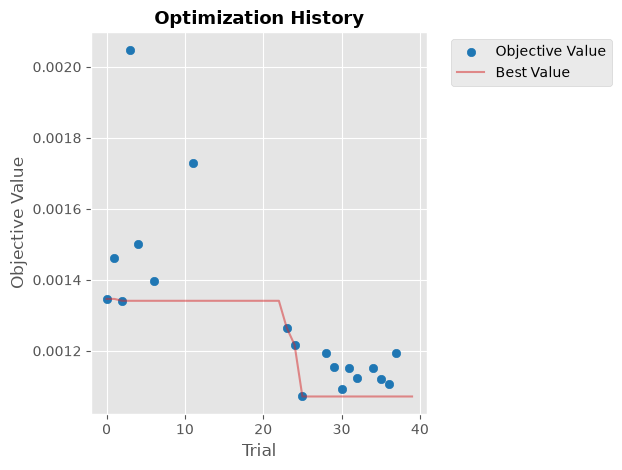

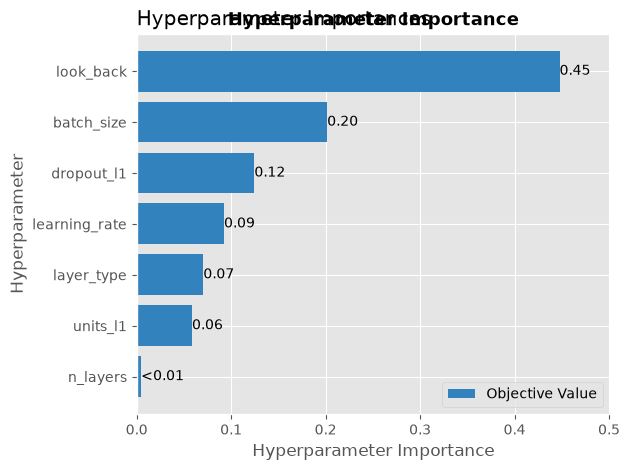

In [12]:
# Catatan: plot_optimization_history & plot_param_importances membuat
# figure-nya sendiri (tidak menerima parameter ax), jadi ditampilkan terpisah.

ax_history = plot_optimization_history(study)
ax_history.set_title("Optimization History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

ax_importance = plot_param_importances(study)
ax_importance.set_title("Hyperparameter Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


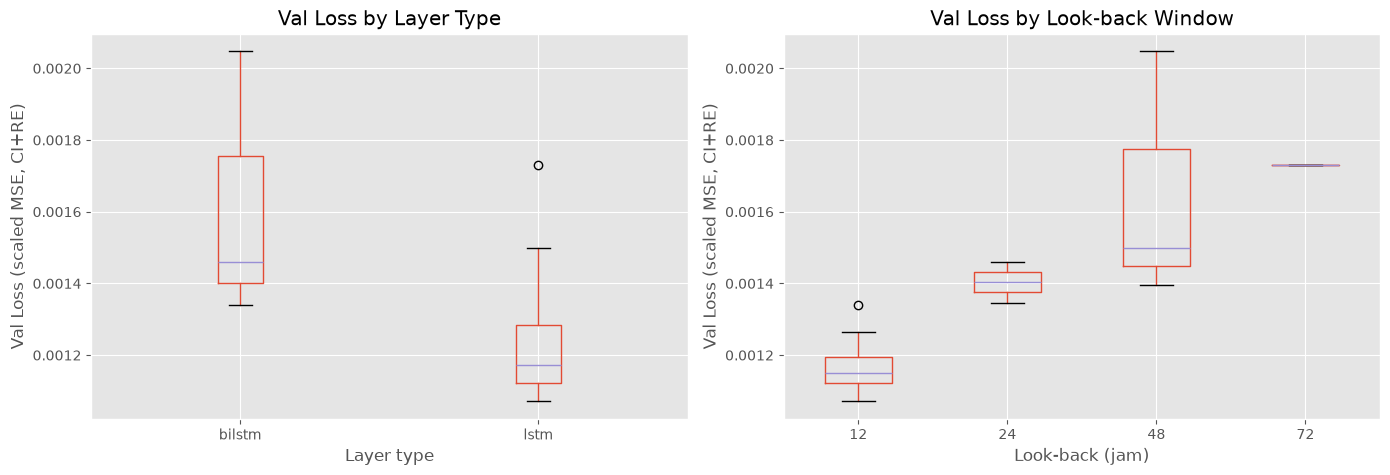

In [13]:
completed = trials_df[trials_df["state"] == "COMPLETE"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

completed.boxplot(column="value", by="params_layer_type", ax=axes[0])
axes[0].set_title("Val Loss by Layer Type")
axes[0].set_xlabel("Layer type")
axes[0].set_ylabel("Val Loss (scaled MSE, CI+RE)")

completed.boxplot(column="value", by="params_look_back", ax=axes[1])
axes[1].set_title("Val Loss by Look-back Window")
axes[1].set_xlabel("Look-back (jam)")
axes[1].set_ylabel("Val Loss (scaled MSE, CI+RE)")

plt.suptitle("")
plt.tight_layout()
plt.show()


### Melatih ulang konfigurasi terbaik

Selama pencarian, `EarlyStopping(patience=10)` dipakai supaya trial cepat selesai. Untuk model final, konfigurasi terbaik dilatih ulang dari awal dengan `patience` lebih longgar (`FINAL_PATIENCE`) supaya model benar-benar konvergen, lalu dievaluasi **satu kali** pada test set yang sejak awal disisihkan (belum pernah dilihat Optuna sama sekali).


In [14]:
best_params = study.best_trial.params
best_look_back = best_params["look_back"]
best_layer_type = best_params["layer_type"]
best_n_layers = best_params["n_layers"]
best_learning_rate = best_params["learning_rate"]
best_batch_size = best_params["batch_size"]

best_layer_units = [best_params[f"units_l{i + 1}"] for i in range(best_n_layers)]
best_layer_dropouts = [best_params[f"dropout_l{i + 1}"] for i in range(best_n_layers)]

print("=== ARSITEKTUR TERBAIK ===")
print(f"Look-back  : {best_look_back}")
print(f"Layer type : {best_layer_type}")
print(f"Stacked    : {best_n_layers} layer -> units={best_layer_units}, dropout={best_layer_dropouts}")
print(f"LR         : {best_learning_rate:.6f}")
print(f"Batch size : {best_batch_size}")


X_train_best, y_train_best = loader.create_sliding_window(
    train_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=best_look_back,
    forecast_horizon=FORECAST_HORIZON
)


def create_test_window(train_df, test_df, target_cols, look_back, forecast_horizon=1):
    context = pd.concat([
        train_df.iloc[-look_back:],
        test_df
    ])
    return loader.create_sliding_window(
        context,
        target_cols=target_cols,
        look_back=look_back,
        forecast_horizon=forecast_horizon
    )


X_test_best, y_test_best = create_test_window(
    train_multi_scaled,
    test_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=best_look_back,
    forecast_horizon=FORECAST_HORIZON
)

print(f"\nX_train={X_train_best.shape}, y_train={y_train_best.shape}")
print(f"X_test ={X_test_best.shape}, y_test ={y_test_best.shape}")


=== ARSITEKTUR TERBAIK ===
Look-back  : 12
Layer type : lstm
Stacked    : 1 layer -> units=[128], dropout=[0.0]
LR         : 0.001847
Batch size : 64
  Sliding window: X=(13984, 12, 84), y=(13984, 2)
  Sliding window: X=(3500, 12, 84), y=(3500, 2)

X_train=(13984, 12, 84), y_train=(13984, 2)
X_test =(3500, 12, 84), y_test =(3500, 2)


In [15]:
tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)

FINAL_EPOCHS = 100
FINAL_PATIENCE = 15

model_final = build_model(
    input_shape=(X_train_best.shape[1], X_train_best.shape[2]),
    output_dim=2,
    layer_type=best_layer_type,
    layer_units=best_layer_units,
    layer_dropouts=best_layer_dropouts,
    learning_rate=best_learning_rate
)

model_final.summary()

early_stopping_final = EarlyStopping(
    monitor="val_loss",
    patience=FINAL_PATIENCE,
    restore_best_weights=True
)

print("\n=== RETRAINING BEST CONFIGURATION (FULL CONVERGENCE) ===")
history_final = model_final.fit(
    X_train_best,
    y_train_best,
    validation_split=VALIDATION_SPLIT,
    epochs=FINAL_EPOCHS,
    batch_size=best_batch_size,
    callbacks=[early_stopping_final],
    shuffle=False,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       109,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,314 (427.01 KB)

 Trainable params: 109,314 (427.01 KB)

 Non-trainable params: 0 (0.00 B)


=== RETRAINING BEST CONFIGURATION (FULL CONVERGENCE) ===
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0191 - mae: 0.0956 - val_loss: 0.0052 - val_mae: 0.0566
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0065 - mae: 0.0635 - val_loss: 0.0051 - val_mae: 0.0548
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0048 - mae: 0.0541 - val_loss: 0.0035 - val_mae: 0.0459
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - mae: 0.0494 - val_loss: 0.0024 - val_mae: 0.0376
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0039 - mae: 0.0492 - val_loss: 0.0022 - val_mae: 0.0361
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - mae: 0.0418 - val_loss: 0.0021 - val_mae: 0.0359
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - mae: 0.0420 - val_loss: 0.0019 - val_mae: 0.0341
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0027 - mae: 0.0404 - val_loss: 0.0019 - val_ma

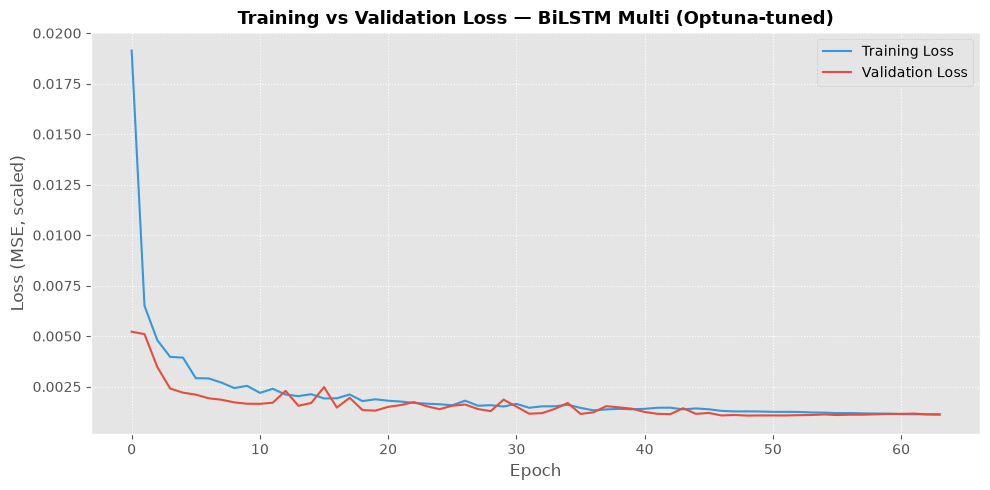

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history_final.history["loss"], label="Training Loss", color="#3498db")
plt.plot(history_final.history["val_loss"], label="Validation Loss", color="#e74c3c")
plt.title(
    "Training vs Validation Loss — BiLSTM Multi (Optuna-tuned)",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, scaled)")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


In [17]:
pred_final_scaled = model_final.predict(X_test_best, verbose=0)

pred_final_inv = loader_multi.inverse_transform_predictions(
    pred_final_scaled,
    target_cols=[CI_COL, RE_COL],
    feature_cols=feature_cols_multi
)

y_final_inv = loader_multi.inverse_transform_predictions(
    y_test_best,
    target_cols=[CI_COL, RE_COL],
    feature_cols=feature_cols_multi
)

print("Prediksi + inverse transform selesai.")
print("Shape prediksi:", pred_final_inv.shape)
print("Shape aktual  :", y_final_inv.shape)


Prediksi + inverse transform selesai.
Shape prediksi: (3500, 2)
Shape aktual  : (3500, 2)


In [18]:
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if not np.any(mask):
        return np.nan

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = safe_mape(y_true, y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)

    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}


tuned_results = [
    {
        "Model": "BiLSTM Multi (Optuna-tuned)",
        "Target": "CI",
        **regression_metrics(y_final_inv[:, 0], pred_final_inv[:, 0])
    },
    {
        "Model": "BiLSTM Multi (Optuna-tuned)",
        "Target": "RE",
        **regression_metrics(y_final_inv[:, 1], pred_final_inv[:, 1])
    }
]

tuned_results_df = pd.DataFrame(tuned_results)

print("=== EVALUASI MODEL HASIL TUNING (TEST SET) ===")
display(tuned_results_df)


=== EVALUASI MODEL HASIL TUNING (TEST SET) ===


,Model,Target,MAE,RMSE,MAPE (%),R2
0,BiLSTM Multi (Optuna-tuned),CI,1.746645,2.259407,0.299344,0.93719
1,BiLSTM Multi (Optuna-tuned),RE,0.181667,0.236209,1.151989,0.94883


In [19]:
baseline_path = results_dir / "05_dani_dl_cyclical_metrics.csv"

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    baseline_bilstm_multi = baseline_df[baseline_df["Model"] == "BiLSTM Multi"].copy()

    comparison_rows = []
    for target in ["CI", "RE"]:
        base_row = baseline_bilstm_multi[baseline_bilstm_multi["Target"] == target].iloc[0]
        tuned_row = tuned_results_df[tuned_results_df["Target"] == target].iloc[0]

        for metric in ["MAE", "RMSE", "MAPE (%)"]:
            base_val = base_row[metric]
            tuned_val = tuned_row[metric]
            improvement_pct = (
                (base_val - tuned_val) / base_val * 100
                if base_val != 0 else np.nan
            )

            comparison_rows.append({
                "Target": target,
                "Metric": metric,
                "Baseline (nb05)": base_val,
                "Tuned (nb06)": tuned_val,
                "Improvement (%)": improvement_pct
            })

    comparison_df = pd.DataFrame(comparison_rows)

    print("=== BASELINE (nb05) vs OPTUNA-TUNED (nb06) ===")
    display(comparison_df)

    comparison_path = results_dir / "06_baseline_vs_tuned_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print("\nComparison disimpan ke:", comparison_path)
else:
    print(f"File baseline tidak ditemukan: {baseline_path}")
    print("Lewati perbandingan — pastikan notebook 05 sudah dijalankan terlebih dahulu.")


=== BASELINE (nb05) vs OPTUNA-TUNED (nb06) ===


,Target,Metric,Baseline (nb05),Tuned (nb06),Improvement (%)
0,CI,MAE,1.973882,1.746645,11.512185
1,CI,RMSE,2.513051,2.259407,10.093070
2,CI,MAPE (%),0.338596,0.299344,11.592443
3,RE,MAE,0.219049,0.181667,17.065676
4,RE,RMSE,0.280200,0.236209,15.699998
5,RE,MAPE (%),1.381246,1.151989,16.597796



Comparison disimpan ke: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_baseline_vs_tuned_comparison.csv


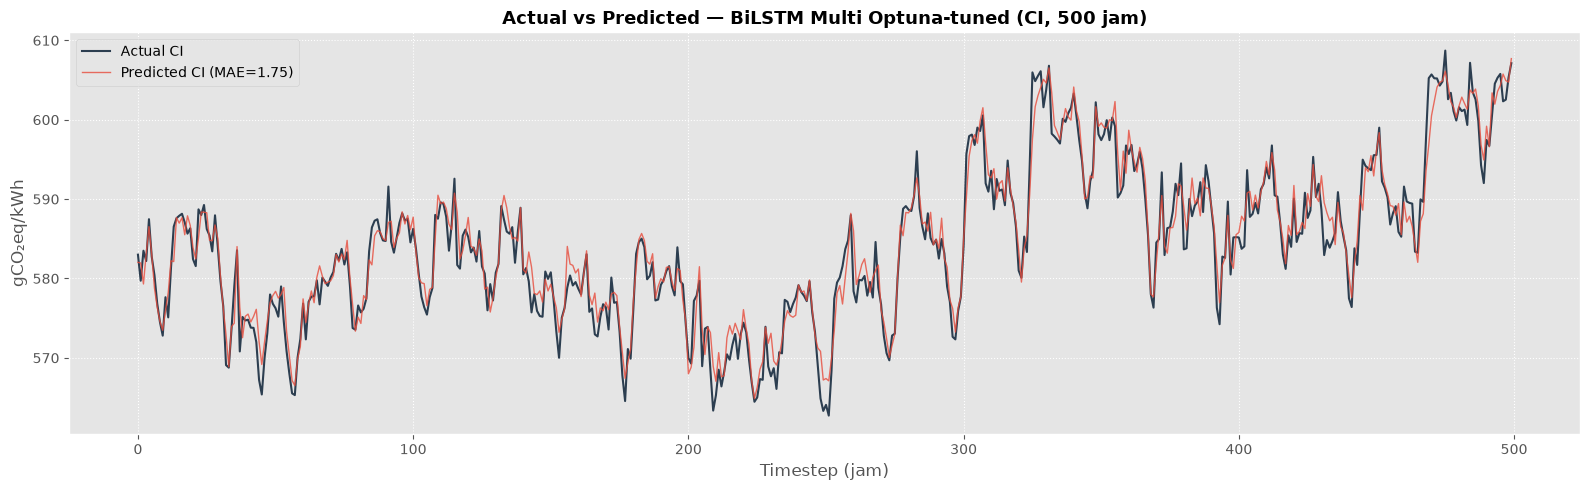

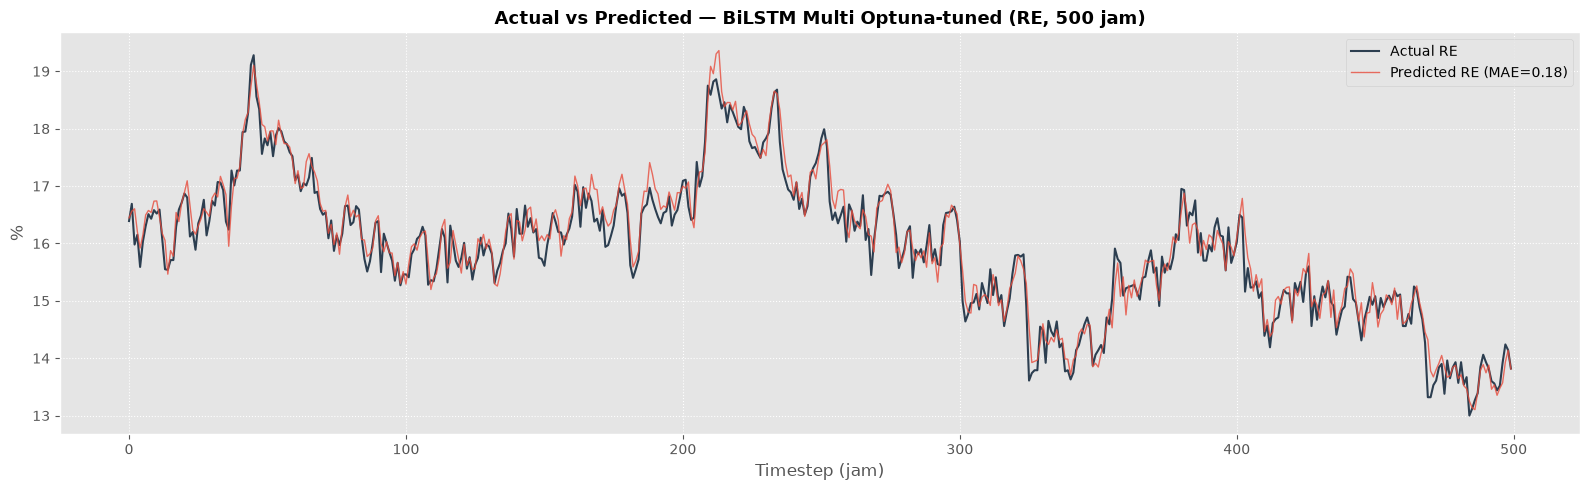

In [20]:
def plot_final_evaluation(y_true, y_pred, target_name, unit, plot_hours=500):
    mae = np.mean(np.abs(y_true - y_pred))
    plot_hours = min(plot_hours, len(y_true))

    plt.figure(figsize=(16, 5))
    plt.plot(
        y_true[:plot_hours],
        label=f"Actual {target_name}",
        color="#2c3e50",
        linewidth=1.5
    )
    plt.plot(
        y_pred[:plot_hours],
        label=f"Predicted {target_name} (MAE={mae:.2f})",
        color="#e74c3c",
        linewidth=1,
        alpha=0.8
    )
    plt.title(
        f"Actual vs Predicted — BiLSTM Multi Optuna-tuned ({target_name}, {plot_hours} jam)",
        fontsize=13,
        fontweight="bold"
    )
    plt.xlabel("Timestep (jam)")
    plt.ylabel(unit)
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


plot_final_evaluation(y_final_inv[:, 0], pred_final_inv[:, 0], "CI", "gCO₂eq/kWh")
plot_final_evaluation(y_final_inv[:, 1], pred_final_inv[:, 1], "RE", "%")


In [21]:
models_dir = (
    project_root
    / "models"
    / "deep_learning"
)
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "06_bilstm_multi_optuna.keras"
model_final.save(model_path)

final_metrics_path = results_dir / "06_dani_dl_optuna_metrics.csv"
tuned_results_df.to_csv(final_metrics_path, index=False)

print("Model tersimpan  :", model_path)
print("Metrics tersimpan:", final_metrics_path)


Model tersimpan  : /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/models/deep_learning/06_bilstm_multi_optuna.keras
Metrics tersimpan: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/06_dani_dl_optuna_metrics.csv


## Experiment Summary

Notebook ini melakukan hyperparameter tuning dengan Optuna terhadap model **BiLSTM Multivariate + Cyclical** (pemenang dari notebook 05), dengan:

- Objective: rata-rata *scaled* validation MSE gabungan CI+RE (equally weighted lewat Min-Max scaling)
- Search space "Lengkap": `look_back`, tipe layer (LSTM/BiLSTM), jumlah stacked layer (1–3), units & dropout per layer, learning rate, batch size
- Budget: 40 trial dengan `TPESampler` + `MedianPruner`
- Test set disisihkan sepenuhnya selama pencarian; hanya dipakai sekali di akhir untuk evaluasi model final

**Artefak yang dihasilkan**
- `results/deep_learning/06_optuna_trials.csv` — riwayat seluruh trial
- `results/deep_learning/06_best_hyperparameters.json` — hyperparameter terbaik
- `results/deep_learning/06_optuna_study.pkl` — objek study (bisa di-*resume*/dianalisis ulang)
- `results/deep_learning/06_dani_dl_optuna_metrics.csv` — metrik model final (test set)
- `results/deep_learning/06_baseline_vs_tuned_comparison.csv` — perbandingan vs baseline nb05
- `models/deep_learning/06_bilstm_multi_optuna.keras` — model final tersimpan

**Langkah selanjutnya**
- Bandingkan hasil model ini dengan komponen Prophet untuk tahap hybrid LSTM-Prophet
- Jika dibutuhkan, notebook lanjutan (07) bisa memperluas tuning ini ke skema *multistep-ahead* forecasting
